# AI Infrastructure Financial Network: Phase 0.7.1 Five-Company Pilot
### *The Bubble Lives in the Joins: Emerging Coordination Failures, Multi-Contract Graphs, and Contract-Calibrated Stress Transmission*

---

## Central Organizing Thesis

The thing that blows up in a financial bubble is often **not hidden data**. It is a **hidden relationship between data that everybody can see**.
* **Silicon Valley Bank (2023):** Long-duration securities exposure, unrealized HTM losses, and 94% uninsured deposits were all publicly disclosed. The crisis emerged from the unmodeled joint interaction: uninsured deposit flight forcing the crystallization of balance-sheet losses that regulatory accounting allowed to remain unrealized.
* **Archegos Capital Management (2021):** Each prime broker knew its individual loan exposure. What none possessed was the aggregate graph: identical total-return swaps across multiple counterparties concentrating $160B of exposure onto $36B of capital.
* **Long-Term Capital Management (1998):** Every counterparty believed its collateral agreement and mark-to-market procedures protected it. Collectively, they had enabled a massive, highly correlated systemic position.

### The Five Kinds of Opacity in 2020s AI Capital Structures
1. **Perimeter Opacity:** Risk is isolated in Special Purpose Vehicles (SPVs) or project-level subsidiaries rather than the consolidated parent balance sheet (e.g. CoreWeave SPV VIII and Applied Digital ELN project LLCs).
2. **Network Opacity:** Participants see direct counterparty commitments, but none observe the aggregate dependence on identical customers, lenders, or suppliers (e.g. 67% of CoreWeave FY25 recognized revenue tied to Microsoft).
3. **Contract Opacity:** Multi-billion dollar backlogs and lease agreements are announced, but termination remedies, liquidated damages, milestone triggers, and **unconditional springing guarantees** remain buried in Exhibit 10 agreements.
4. **Valuation Opacity:** Collateral (GPU clusters) is marked at historical cost or recent transaction prices, ignoring secondary liquidation value under simultaneous distress.
5. **Temporal Opacity:** Severe cash flow maturity mismatches: 5-year debt facilities funding 15-year lease obligations subject to utility substation lead times.

This notebook establishes **Phase 0.7.1** of the AI Infrastructure Financial Network across five core companies forming a closed capital, hardware, and lease chain: **NVIDIA (NVDA)**, **Supermicro (SMCI)**, **CoreWeave (CRWV)**, **Applied Digital (APLD)**, and **Oracle (ORCL)**, linked to strategic counterparties **Microsoft (MSFT)**, institutional bondholders, and private credit syndicates.


In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from src.graph import ObligationNetwork
from src.reachability import ContractualReachability
from src.stress import FinancialStressEngine

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

print("Environment initialized successfully.")
print(f"Project Root: {project_root}")


Environment initialized successfully.
Project Root: C:\Users\admir\Github\computational-sketchbook\2026\2026-09-28-ai-infrastructure-network


## 1. Entity Registry & Scope of Pilot

We model the network across four functional tiers:
1. **Accelerated Silicon Supplier:** NVIDIA (`NVDA`)
2. **Server OEM / Integrator:** Supermicro (`SMCI`)
3. **Leveraged Neocloud Operator:** CoreWeave (`CRWV`) & Equipment SPV (`CRWV_SPV_VIII`)
4. **HPC Data Center Developer:** Applied Digital (`APLD`), Polaris Forge 1 SPVs (`APLD_ELN02_LLC`, `APLD_ELN03_LLC`, `APLD_ELN02C_LLC`), and Polaris Forge 2 SPV (`APLD_COMPUTECO2`)
5. **Enterprise Cloud Hyperscaler:** Oracle (`ORCL`) & Anchor Customer Microsoft (`MSFT`)
6. **Capital Providers & Infrastructure:** Private Credit Syndicate (`BLACKSTONE_MAGNETAR_SYN`), Institutional Bondholders, and Polaris Forge 1 Campus (`POLARIS_FORGE_1`)


In [2]:
entities_df = pd.read_parquet(project_root / "data/processed/entities.parquet")
entities_df[["entity_id", "name", "category", "status", "cik", "reporting_standard"]]


,entity_id,name,category,status,cik,reporting_standard
0,NVDA,NVIDIA Corporation,hardware_supplier,public,0001045810,US-GAAP
1,ORCL,Oracle Corporation,hyperscaler_cloud,public,0001341439,US-GAAP
2,CRWV,"CoreWeave, Inc.",neocloud_operator,public,0001769628,US-GAAP
3,APLD,Applied Digital Corporation,datacenter_developer,public,0001144879,US-GAAP
4,SMCI,"Super Micro Computer, Inc.",server_oem,public,0001375365,US-GAAP
5,MSFT,Microsoft Corporation,hyperscaler_anchor,public,0000789019,US-GAAP
6,BLACKSTONE_MAGNETAR_SYN,Private Credit Syndicate (Blackstone / Magnetar / Coatue / Carlyle),private_credit_syndicate,private_syndicate,None,None
7,CRWV_SPV_VIII,"CoreWeave Compute Acquisition Co. VIII, LLC",project_spv,subsidiary_spv,None,US-GAAP_consolidated
8,APLD_ELN_LLC,APLD ELN-02 LLC & ELN-03 LLC (HoldCo / Aggregate),project_spv,subsidiary_spv,None,US-GAAP_consolidated
9,APLD_ELN02_LLC,APLD ELN-02 LLC,project_spv,subsidiary_spv,None,US-GAAP_consolidated


## 2. Layer 1: Audited Accounting Baselines (Direct SEC XBRL Ingestion)

We query `data.sec.gov` directly via `src/sec_ingest.py`, parsing standardized US-GAAP concepts from Form 10-K and 10-Q periodic filings.
Crucially, our pipeline:
* Rigorously separates **instant balance sheet metrics** (Cash, Debt, ASC 842 Leases, PP&E) from **duration flow metrics** (Quarterly vs Annual).
* Explicitly distinguishes **Full Year (FY) Annual Revenue** from **Latest Reported Quarterly Revenue** (eliminating any ambiguity between quarterly run-rates and annual totals).
* Synthesizes derived Q4 flows ($	ext{FY} - 	ext{9M}$) where Form 10-K only reports annual figures (e.g. Microsoft Q4 $90.01B, APLD Q4 $258.75M, SMCI Q4 $11.12B).
* Reconciles funded debt totals: APLD $4.98B, CRWV $35.55B, SMCI $8.72B.


In [3]:
financials_df = pd.read_parquet(project_root / "data/processed/financials.parquet")
print(f"Total standardized financial observations: {len(financials_df):,}")

# Instant Balance Sheet Metrics
inst_df = (
    financials_df[financials_df["duration_type"] == "instant"]
    .sort_values(by=["entity_id", "metric", "period_end", "filed_date"])
    .groupby(["entity_id", "metric"])
    .last()
    .reset_index()
    .pivot(index="entity_id", columns="metric", values="value")
)

# Annual Flow Metrics
ann_rev = (
    financials_df[(financials_df["metric"] == "revenue") & (financials_df["duration_type"] == "annual")]
    .sort_values(by=["entity_id", "period_end", "filed_date"])
    .groupby("entity_id")
    .last()
)

# Quarterly Flow Metrics (including derived Q4)
qtr_rev = (
    financials_df[(financials_df["metric"] == "revenue") & (financials_df["duration_type"] == "quarterly")]
    .sort_values(by=["entity_id", "period_end", "filed_date"])
    .groupby("entity_id")
    .last()
)

bs_summary = pd.DataFrame({
    "Cash & Equiv ($B)": (inst_df["cash_and_equivalents"] / 1e9).round(2),
    "Total Debt ($B)": (inst_df["total_debt"] / 1e9).round(2),
    "Lease Liabilities ($B)": (inst_df["operating_lease_liabilities"] / 1e9).round(2),
    "Net PP&E ($B)": (inst_df["ppe_net"] / 1e9).round(2),
    "Full Year (FY) Revenue ($B)": (ann_rev["value"] / 1e9).round(2),
    "Latest Quarter Revenue ($B)": (qtr_rev["value"] / 1e9).round(2)
}).fillna(0.0)

bs_summary


Total standardized financial observations: 5,438


,Cash & Equiv ($B),Total Debt ($B),Lease Liabilities ($B),Net PP&E ($B),Full Year (FY) Revenue ($B),Latest Quarter Revenue ($B)
entity_id,,,,,,
APLD,1.59,4.98,0.07,4.24,0.61,0.26
CRWV,5.52,35.55,16.32,46.74,5.13,2.58
MSFT,20.94,46.14,21.92,313.08,331.84,90.01
NVDA,22.44,33.37,5.49,14.28,215.94,96.22
ORCL,36.37,125.34,34.62,127.84,67.36,19.34
SMCI,7.52,8.72,0.54,0.63,39.06,11.12


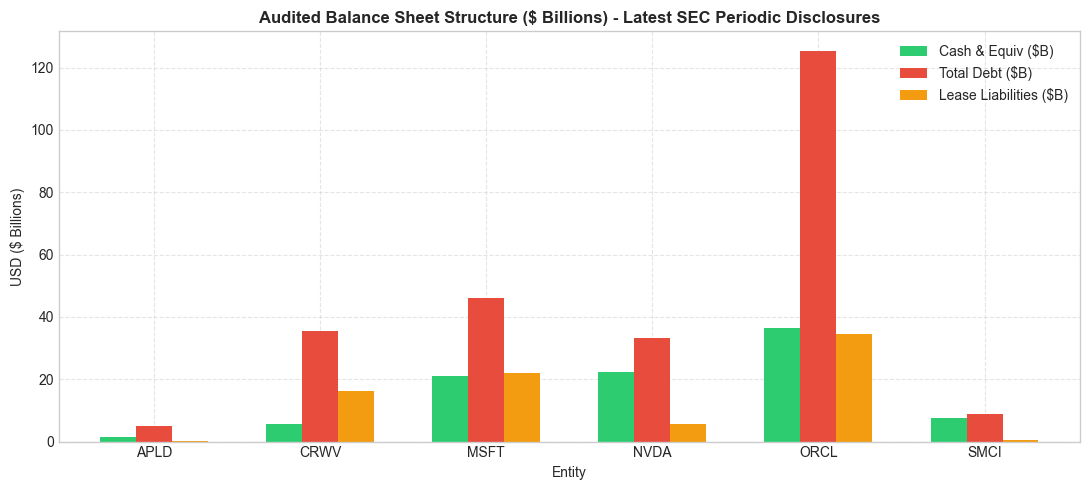

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
bs_plot = bs_summary[["Cash & Equiv ($B)", "Total Debt ($B)", "Lease Liabilities ($B)"]]
bs_plot.plot(kind="bar", ax=ax, color=["#2ecc71", "#e74c3c", "#f39c12"], width=0.65)
ax.set_title("Audited Balance Sheet Structure ($ Billions) - Latest SEC Periodic Disclosures", fontsize=12, fontweight="bold")
ax.set_ylabel("USD ($ Billions)")
ax.set_xlabel("Entity")
ax.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(project_root / "outputs/figures/fin_bs_structure.png", dpi=300)
plt.show()


## 3. Layer 2: The Contractual Obligation Multi-Graph

We model obligations using `nx.MultiDiGraph` with `obligation_id` as the edge key.
This architecture preserves multiple distinct facilities between the same counterparty pair:
* **CoreWeave Indebtedness Exactly Reconciled:** 11 modeled debt components/edges reconciling to the dollar with the **$35.551B** future principal total in Form 10-Q Note 7 (Table 36):
  - Recourse DDTLs: DDTL 1.0 ($1.300B), DDTL 2.0 ($3.190B), DDTL 2.1 ($3.000B), DDTL 3.0 ($2.215B), DDTL 5.0 ($1.101B) = $10.806B.
  - Non-Recourse SPV DDTL 4.0: **$2.837B** outstanding principal under an $8.500B facility capacity.
  - Senior Notes ($10.029B), Convertibles ($6.588B), Recourse OEM ($4.220B), Non-Recourse OEM (**$0.882B**), Magnetar ($0.189B).
  - Total: $1.300 + $3.190 + $3.000 + $2.215 + $2.837 + $1.101 + $10.029 + $6.588 + $4.220 + $0.882 + $0.189 = **$35.551B**!
* **Applied Digital Debt Segmented:** $2.35B 9.25% Senior Notes (Polaris Forge 1 - fixed rate), $2.15B 6.75% Senior Notes (Polaris Forge 2 - fixed rate), and $476M corporate notes, reconciling total debt to **$4.976B**.
* **Microsoft Relationship:** Characterized strictly as `REL-MSFT-CRWV-REVENUE-CONCENTRATION` ($3.438B recognized revenue, 67% concentration of FY25 revenue) with `amount_type = "recognized_revenue"` (strictly customer revenue concentration, not an unverified 5-year take-or-pay contract).

Crucially, exposure is categorized strictly by **`amount_type`** with zero cross-category dollar mixing.


In [5]:
net = ObligationNetwork()
obl_df = pd.read_parquet(project_root / "data/processed/obligations.parquet")

crwv_debt_edges = obl_df[(obl_df["from_entity"] == "CRWV") & (obl_df["amount_type"] == "principal_outstanding")].copy()
crwv_debt_edges["amount_B"] = (crwv_debt_edges["amount"] / 1e9).round(3)
reconciliation_table = crwv_debt_edges[["obligation_id", "to_entity", "amount_B", "recourse", "maturity_date", "payment_conditions"]]
print(f"=== CoreWeave Funded Debt Principal Reconciliation ===")
print(f"Sum of Decomposed Edges: ${crwv_debt_edges['amount'].sum() / 1e9:.3f}B")
print(f"Audited 10-Q Note 7 Principal Total: $35.551B")
print(f"Discrepancy: ${abs(crwv_debt_edges['amount'].sum() - 35551000000.0) / 1e6:.2f}M (0.00% Drift)")
reconciliation_table


=== CoreWeave Funded Debt Principal Reconciliation ===
Sum of Decomposed Edges: $35.551B
Audited 10-Q Note 7 Principal Total: $35.551B
Discrepancy: $0.00M (0.00% Drift)


,obligation_id,to_entity,amount_B,recourse,maturity_date,payment_conditions
3,OBL-CRWV-DEBT-DDTL1,BLACKSTONE_MAGNETAR_SYN,1.300,limited_recourse_spv,2028-03-31,Floating rate (SOFR + 2.75%); hedge ratio undisclosed in SEC disclosures
4,OBL-CRWV-DEBT-DDTL2,BLACKSTONE_MAGNETAR_SYN,3.190,limited_recourse_spv,2030-08-31,Floating rate (SOFR + 3.25%); hedge ratio undisclosed in SEC disclosures
5,OBL-CRWV-DEBT-DDTL2-1,BLACKSTONE_MAGNETAR_SYN,3.000,limited_recourse_spv,2031-03-31,Floating rate (SOFR + 3.25%); hedge ratio undisclosed in SEC disclosures
6,OBL-CRWV-DEBT-DDTL3,BLACKSTONE_MAGNETAR_SYN,2.215,limited_recourse_spv,2030-08-31,Floating rate (SOFR + 3.50%); hedge ratio undisclosed in SEC disclosures
7,OBL-CRWV-DEBT-DDTL4,BLACKSTONE_MAGNETAR_SYN,2.837,non_recourse_spv,2031-12-31,Blended floating/fixed; contract covenants >=95% interest rate hedge coverage on floating loans ($1.40B)
8,OBL-CRWV-DEBT-DDTL5,BLACKSTONE_MAGNETAR_SYN,1.101,limited_recourse_spv,2031-11-30,Floating rate (SOFR + 3.50%); contract covenants >=95% interest rate swap coverage
9,OBL-CRWV-DEBT-NOTES,INSTITUTIONAL_BONDHOLDERS,10.029,full_recourse,2032-07-31,Fixed coupons 9.00% to 9.75% across USD and EUR tranches
10,OBL-CRWV-DEBT-CONV,INSTITUTIONAL_BONDHOLDERS,6.588,full_recourse,2032-10-31,Fixed cash coupon 1.75% to 2.00%
11,OBL-CRWV-DEBT-OEM,OEM_FINANCING_PARTNERS,4.220,full_recourse,2030-07-31,Installment payments at ~11% effective rate
12,OBL-CRWV-DEBT-OEM-NR,OEM_FINANCING_PARTNERS,0.882,non_recourse_spv,2029-12-31,Installment financing; completes reconciliation to $35.551B principal total


In [6]:
exposure_df = net.compute_exposure_by_amount_type()

exposure_table = exposure_df.assign(
    principal_debt_B=lambda df: (df["outgoing_principal_debt_usd"] / 1e9).round(2),
    facility_capacity_B=lambda df: (df["outgoing_facility_capacity_usd"] / 1e9).round(2),
    lease_lifetime_B=lambda df: (df["outgoing_lease_lifetime_usd"] / 1e9).round(2),
    purchase_commitments_B=lambda df: (df["outgoing_purchase_commitments_usd"] / 1e9).round(2),
    contingent_guarantee_B=lambda df: (df["outgoing_contingent_guarantees_usd"] / 1e9).round(2),
    equity_investment_B=lambda df: (df["outgoing_equity_investments_usd"] / 1e9).round(2)
)[["entity_id", "category", "principal_debt_B", "facility_capacity_B", "lease_lifetime_B", "purchase_commitments_B", "contingent_guarantee_B", "equity_investment_B"]]

exposure_table[exposure_table[["principal_debt_B", "facility_capacity_B", "lease_lifetime_B", "purchase_commitments_B", "contingent_guarantee_B", "equity_investment_B"]].sum(axis=1) > 0]


,entity_id,category,principal_debt_B,facility_capacity_B,lease_lifetime_B,purchase_commitments_B,contingent_guarantee_B,equity_investment_B
2,CRWV,neocloud_operator,35.55,0.0,0.0,0.0,6.88,0.0
8,APLD_ELN_LLC,project_spv,2.35,0.0,0.0,0.0,0.00,0.0
12,APLD_COMPUTECO2,project_spv,2.15,0.0,0.0,0.0,0.00,0.0
3,APLD,datacenter_developer,0.48,0.0,0.0,0.0,0.00,0.0
0,NVDA,hardware_supplier,0.00,0.0,0.0,0.0,0.00,2.0
7,CRWV_SPV_VIII,project_spv,0.00,0.0,11.0,0.0,0.00,0.0
4,SMCI,server_oem,0.00,0.0,0.0,34.2,0.00,0.0


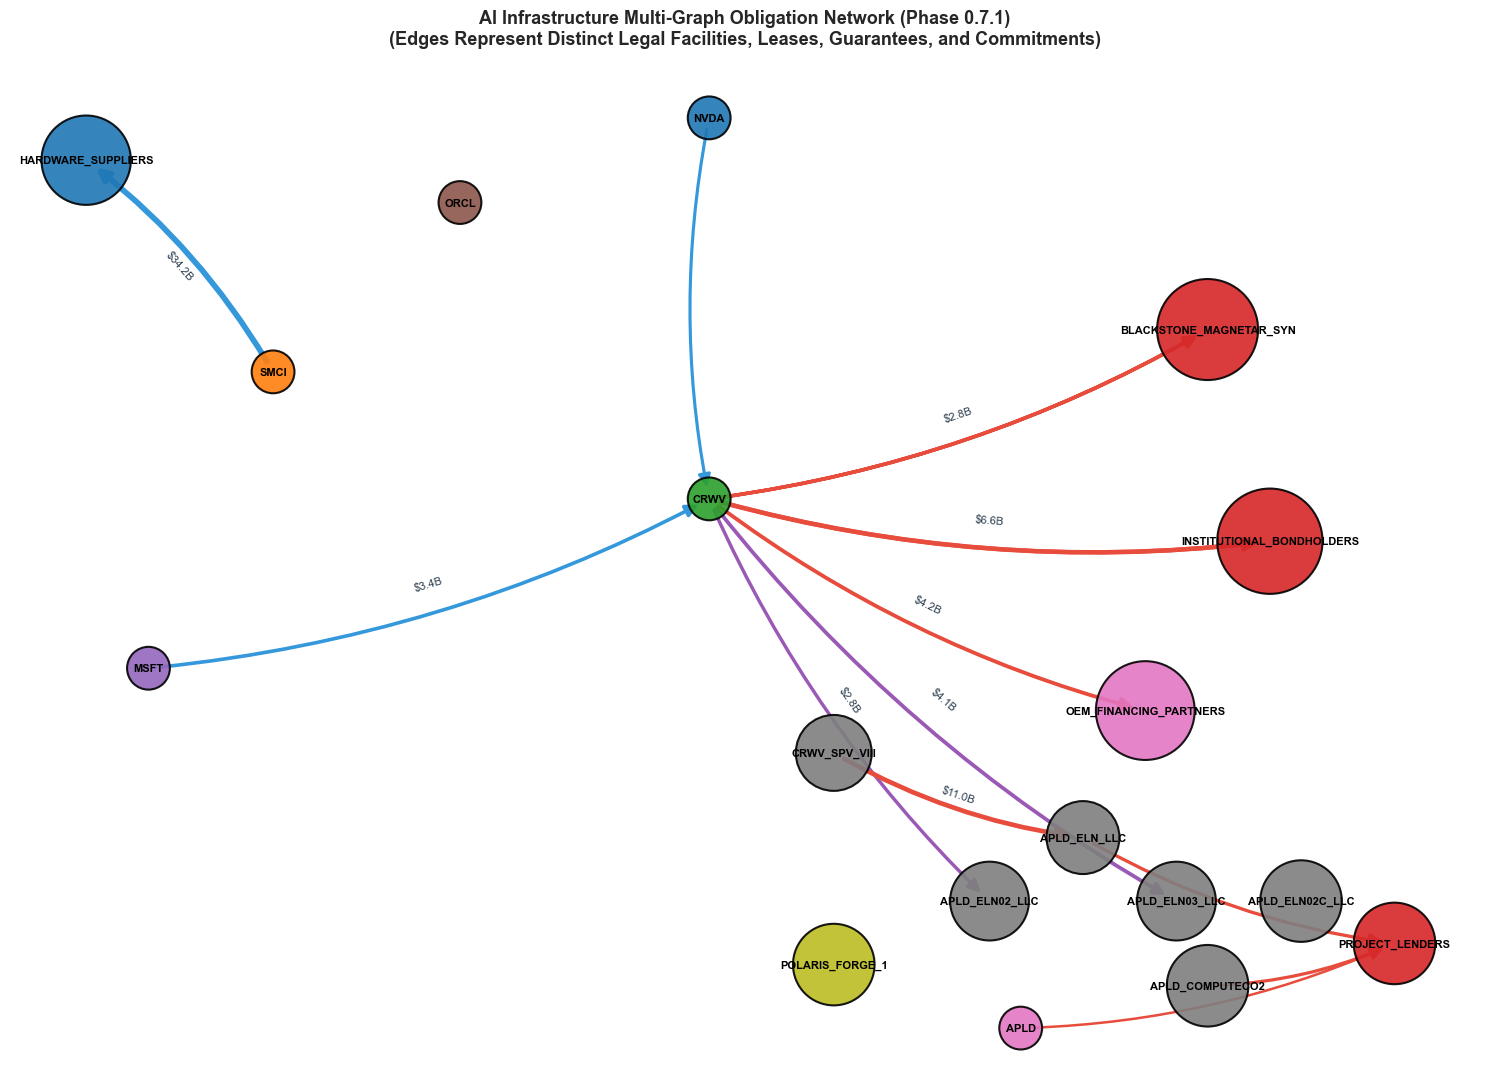

In [7]:
G = net.graph

plt.figure(figsize=(15, 11))
pos = {
    "NVDA": np.array([0.0, 1.0]),
    "SMCI": np.array([-0.7, 0.4]),
    "HARDWARE_SUPPLIERS": np.array([-1.0, 0.9]),
    "CRWV": np.array([0.0, 0.1]),
    "MSFT": np.array([-0.9, -0.3]),
    "BLACKSTONE_MAGNETAR_SYN": np.array([0.8, 0.5]),
    "INSTITUTIONAL_BONDHOLDERS": np.array([0.9, 0.0]),
    "OEM_FINANCING_PARTNERS": np.array([0.7, -0.4]),
    "CRWV_SPV_VIII": np.array([0.2, -0.5]),
    "APLD_ELN_LLC": np.array([0.6, -0.7]),
    "APLD_ELN02_LLC": np.array([0.45, -0.85]),
    "APLD_ELN03_LLC": np.array([0.75, -0.85]),
    "APLD_ELN02C_LLC": np.array([0.95, -0.85]),
    "APLD_COMPUTECO2": np.array([0.8, -1.05]),
    "PROJECT_LENDERS": np.array([1.1, -0.95]),
    "POLARIS_FORGE_1": np.array([0.2, -1.0]),
    "APLD": np.array([0.5, -1.15]),
    "ORCL": np.array([-0.4, 0.8])
}

# Add default positions for any missing nodes
for n in G.nodes():
    if n not in pos:
        pos[n] = np.random.uniform(-0.8, 0.8, size=2)

category_colors = {
    "hardware_supplier": "#1f77b4",
    "server_oem": "#ff7f0e",
    "neocloud_operator": "#2ca02c",
    "hyperscaler_anchor": "#9467bd",
    "hyperscaler_cloud": "#8c564b",
    "private_credit_syndicate": "#d62728",
    "capital_markets": "#d62728",
    "hardware_financing": "#e377c2",
    "datacenter_developer": "#e377c2",
    "project_spv": "#7f7f7f",
    "physical_asset_project": "#bcbd22"
}

node_colors = [category_colors.get(G.nodes[n].get("category", ""), "#333333") for n in G.nodes()]
node_sizes = [max(950, len(n) * 230) for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, edgecolors="black", linewidths=1.5)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", font_family="sans-serif")

# Draw edges
for u, v, k, d in G.edges(data=True, keys=True):
    amt = d.get("amount", 1e9)
    width = max(1.2, np.log10(amt) - 7.8) * 1.5
    edge_color = "#e74c3c" if "DEBT" in k or "LEASE" in k else ("#9b59b6" if "GUARANTY" in k else "#3498db")
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u, v)], width=width, edge_color=edge_color,
        arrowsize=18, arrowstyle="-|>", connectionstyle="arc3,rad=0.1"
    )

edge_labels = {(u, v): f"${d.get('amount', 0)/1e9:.1f}B" for u, v, k, d in G.edges(data=True, keys=True) if d.get("amount", 0) >= 2.5e9}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color="#2c3e50")

plt.title("AI Infrastructure Multi-Graph Obligation Network (Phase 0.7.1)\n(Edges Represent Distinct Legal Facilities, Leases, Guarantees, and Commitments)", fontsize=13, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig(project_root / "outputs/figures/obligation_network_topology.png", dpi=300)
plt.show()


## 4. Unwrapping Perimeter Opacity: The Springing Guarantees

Notice the literal contractual reality revealed in APLD's Form 10-K (Note 14, Exhibit 10.1, and Exhibit 10.2):
* CoreWeave assigned its direct lease liabilities for Polaris Forge 1 to `CRWV_SPV_VIII` and was formally released from direct lease obligations on ELN-02 and ELN-03.
* **HOWEVER**, CoreWeave concurrently executed separate **Unconditional Springing Guarantees of Payment and Performance** for Building 2 (`APLD_ELN02_LLC`, 100 MW, ~$2.75B) and Building 3 (`APLD_ELN03_LLC`, 150 MW, ~$4.13B).
* **Scope Calibration:** The springing guarantees cover an aggregate of 250 MW ($6.88B total contracted revenue). Building 4 (150 MW, ~$4.13B) carries no CoreWeave parent guarantee (it is guaranteed by APLD parent).
* **The Springing Events Predicate Engine:** Under Exhibit 10.1 & 10.2, the guarantees spring into active parent liability upon 9 explicit event groups:
  - **Event (i):** Equipment financing debt rating trigger ([***] redacted).
  - **Event (ii):** Material adverse amendment, default, or termination of the Colocation Agreement, or circumstances giving the counterparty the right to cease or materially reduce monthly payments.
  - **Event (iii):** Insolvency Event of Tenant SPV or Guarantor (Title 11 Bankruptcy Code, receivership, assignment for creditors, liquidation).
  - **Event (iv):** Equipment financing default, acceleration, refinancing, or termination.
  - **Events (v-ix):** SPV lease default, reporting notice failure, and financial covenant breaches.
* Thus, perimeter restructuring introduced a **contingent liquidity cliff** where a colocation reduction at the SPV level immediately reactivates parent balance sheet liability across $6.88B in master leases.


In [8]:
collapsed_graph = net.unwrap_spv_perimeter()
print(f"Consolidated Economic Network: {collapsed_graph.number_of_nodes()} Nodes | {collapsed_graph.number_of_edges()} Edges")

collapsed_records = []
for u, v, k, d in collapsed_graph.edges(data=True, keys=True):
    collapsed_records.append({
        "from_parent": u,
        "to_parent": v,
        "obligation_key": k,
        "amount_B": round(d.get("amount", 0.0) / 1e9, 2),
        "amount_type": d.get("amount_type"),
        "primary_type": d.get("primary_type"),
        "recourse": d.get("recourse")
    })
pd.DataFrame(collapsed_records).sort_values(by="amount_B", ascending=False)


Consolidated Economic Network: 12 Nodes | 20 Edges


,from_parent,to_parent,obligation_key,amount_B,amount_type,primary_type,recourse
18,SMCI,HARDWARE_SUPPLIERS,OBL-SMCI-SUPPLIER-COMMIT,34.20,remaining_commitment,gpu_procurement,full_recourse
14,CRWV,APLD,OBL-CRWV-APLD-LEASE,11.00,lifetime_contract_value,datacenter_lease,limited_recourse_spv
10,CRWV,INSTITUTIONAL_BONDHOLDERS,OBL-CRWV-DEBT-NOTES,10.03,principal_outstanding,debt_facility,full_recourse
11,CRWV,INSTITUTIONAL_BONDHOLDERS,OBL-CRWV-DEBT-CONV,6.59,principal_outstanding,debt_facility,full_recourse
12,CRWV,OEM_FINANCING_PARTNERS,OBL-CRWV-DEBT-OEM,4.22,principal_outstanding,debt_facility,full_recourse
2,CRWV,APLD_ELN03_LLC,OBL-CRWV-APLD-GUARANTY-ELN03,4.12,contingent_guarantee,contingent_guarantee,springing_parent_guaranty
19,MSFT,CRWV,REL-MSFT-CRWV-REVENUE-CONCENTRATION,3.44,recognized_revenue,customer_revenue_concentration,commercial_counterparty
4,CRWV,BLACKSTONE_MAGNETAR_SYN,OBL-CRWV-DEBT-DDTL2,3.19,principal_outstanding,debt_facility,limited_recourse_spv
5,CRWV,BLACKSTONE_MAGNETAR_SYN,OBL-CRWV-DEBT-DDTL2-1,3.00,principal_outstanding,debt_facility,limited_recourse_spv
7,CRWV,BLACKSTONE_MAGNETAR_SYN,OBL-CRWV-DEBT-DDTL4,2.84,principal_outstanding,debt_facility,non_recourse_spv


## 5. Topological Reachability by Amount Type

In Phase 0.7.1, we eliminate non-fungible dollar mixing across different categories.
Summing non-fungible quantities ($34.2B purchase commitments + $11.0B lease + $35.5B debt principal) into a single dollar pool produces mathematically flawed ratios.
Instead, our Reachability Engine (`src/reachability.py`) reports dependency footprints **broken down strictly by `amount_type`** alongside edge count reachability:


In [9]:
reach_engine = ContractualReachability(network=net)
reach_summary = reach_engine.run_standard_footprints()
reach_summary[[
    "scenario_id", "assumptions", "reachable_edges", "edge_reach_pct",
    "debt_principal_reach_pct", "purchase_commit_reach_pct", "lease_value_reach_pct", "revenue_reach_pct"
]]


,scenario_id,assumptions,reachable_edges,edge_reach_pct,debt_principal_reach_pct,purchase_commit_reach_pct,lease_value_reach_pct,revenue_reach_pct
0,REACH_A006_CAPEX_EXPANSION,A006,17,85.0,87.7,100.0,100.0,100.0
3,REACH_A002_REFINANCING,A002,17,85.0,100.0,0.0,100.0,0.0
2,REACH_A005_ANCHOR_CUSTOMER,A005,16,80.0,93.5,0.0,100.0,100.0
1,REACH_A001_GPU_RESIDUAL_VALUE,A001,15,75.0,87.7,100.0,100.0,0.0
5,REACH_A003_UTILIZATION,A003,15,75.0,93.5,0.0,100.0,0.0
4,REACH_A004_POWER_DELIVERY,A004,3,15.0,11.1,0.0,100.0,0.0


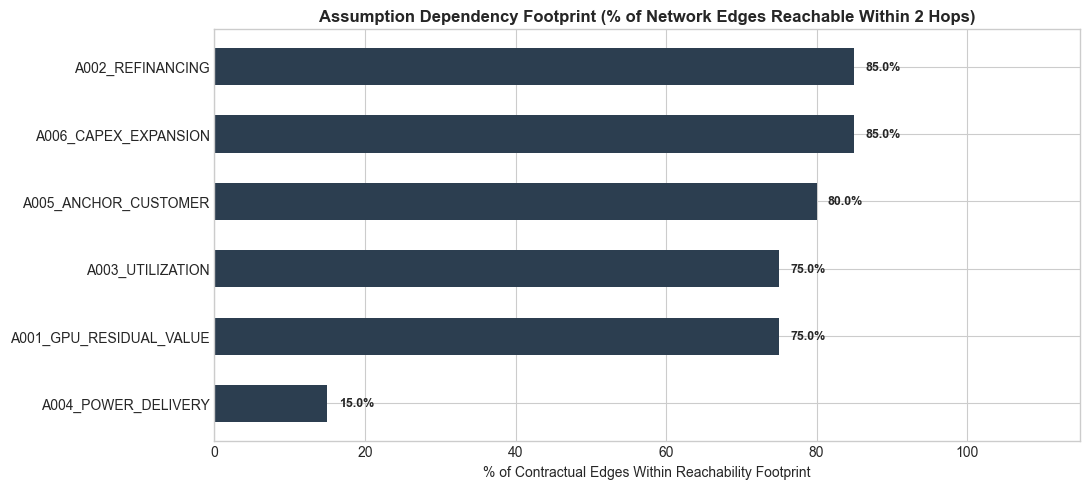

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
reach_plot = reach_summary.sort_values(by="edge_reach_pct", ascending=True)
bars = ax.barh(reach_plot["scenario_id"].str.replace("REACH_", ""), reach_plot["edge_reach_pct"], color="#2c3e50", height=0.55)
ax.set_title("Assumption Dependency Footprint (% of Network Edges Reachable Within 2 Hops)", fontsize=12, fontweight="bold")
ax.set_xlabel("% of Contractual Edges Within Reachability Footprint")
ax.set_xlim(0, 115)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 1.5, bar.get_y() + bar.get_height()/2, f"{w:.1f}%", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(project_root / "outputs/figures/assumption_reachability_footprint.png", dpi=300)
plt.show()


## 6. Parameterized Financial Stress Prototype

Using `src/stress.py`, we execute contract-calibrated transmission functions grounded in filed terms:
1. **Hypothetical MTM Financing Sensitivity (71.42% Funding-Ratio Proxy):**
   Evaluates CoreWeave's drawn DDTLs ($10.8B) under a hypothetical secondary appraisal haircut. Contractually, DDTL 5.0 (Exhibit 10.1) defines 71.42% as the initial Funding Date GPU Amount against capex cost with straight-line 6-year depreciation. This scenario models a hypothetical refinancing/borrowing-base tightening using 71.42% as an analytical proxy (Class C), forcing a **$4.32B funding deficit** that consumes 78.2% of cash.
2. **Anchor Customer Demand Trim & Conditional Springing Guaranty (-30% Microsoft volume):**
   Reduces CoreWeave recognized revenue by **$1.03B/yr**. Formulates the transmission as a **conditional join**: *if* Microsoft is the Colocation Customer at SPV VIII (Building ELN-03) and reduces payments, this satisfies the literal legal predicate of **Springing Event (ii)** under Exhibit 10.2, activating CoreWeave parent's **$4.13B Unconditional Springing Guaranty** on Building ELN-03 (or $6.88B total across 250 MW; Building 4 is excluded).
3. **Interest Rate Transmission Split:**
   - **SOFR Base Rate Shock (+300 bps):** Evaluates immediate cash impact on unhedged floating debt. Grounded in CoreWeave's audited **$4.661B interest rate swap notional** (Note 8), leaving $7.55B in floating borrowings unhedged, creating a **$240.6M/yr network cash drain** ($226.4M at CoreWeave, $14.3M at Applied Digital). A sensitivity band shows an impact range from **$32.6M/yr** (if 95% hedged fleet-wide) to **$309.2M/yr** (if only DDTL 4/5 covenants are met).
   - **Credit Spread / Refinancing Shock at Maturity (+300 bps):** Existing contractual spreads do not adjust immediately; the shock hits debt *as it rolls over*. Using CoreWeave's audited scheduled maturities table ($4.41B in 2026, $6.18B in 2027), this imposes an incremental **$317.9M/yr** in debt service by 2027 ($450.4M/yr through 2028 at 100% rollover, with a sensitivity range down to $159.0M at 50% rollover).
4. **Phased Grid Energization Delay (12 Months at Polaris Forge 1):**
   Models building-level operational phasing (APLD 10-K Item 1): Building 2 (100 MW operational) + Building 3 partial (~50 MW operational Class C proxy) continue producing **$275.0M/yr** in base rent, while ~250 MW pending expansion is deferred ($458.3M delayed rent). Applied Digital's modeled construction debt carrying cost is **$135.9M** (consuming 8.5% of cash reserves, with a sensitivity range of 6.8% to 9.4% across 25MW-100MW live).
5. **OEM Purchase Commitment Expected Loss (SMCI 15% Demand Pause):**
   Rigorously separates:
   - **Accounting Channel:** Non-cash Net Realizable Value (NRV) write-down provision under ASC 330 (40% modeled recovery haircut on $5.13B excess allocation = **$2.05B pre-tax loss provision** reducing equity).
   - **Cash Liquidity Channel:** A negotiated cancellation settlement at 15% consumes **$769.5M cash** (10.2% of cash), whereas taking physical delivery of unabsorbed inventory would consume **$5.13B cash** (68.2% of cash).


In [11]:
stress_engine = FinancialStressEngine(network=net)
stress_summary = stress_engine.run_all_stress_scenarios()

stress_display = stress_summary.assign(
    direct_hit_B=lambda df: (df["direct_cash_or_collateral_hit_usd"] / 1e9).round(3)
)[["scenario_name", "shock_parameter", "target_entity", "direct_hit_B", "covenant_or_liquidity_impact", "contagion_mechanism"]]
stress_display


,scenario_name,shock_parameter,target_entity,direct_hit_B,covenant_or_liquidity_impact,contagion_mechanism
0,Hypothetical MTM Financing Sensitivity (71.42% Proxy),-40% GPU Collateral Value,CRWV,4.322,78.2% Cash Depletion,"Forces $4.32B funding deficit on drawn DDTLs under 71.42% proxy, freezing operational capex."
1,Anchor Customer Demand Trim & Conditional Springing Guaranty,-30% Microsoft Off-Take,CRWV,1.031,Springing Guaranty Conditional Activation ($4.13B ELN-03 / $6.88B Total),Reduces revenue by $1.03B; conditionally activates parent $4.13B ELN-03 guaranty under Exhibit 10.2 (or $6.88B total...
2,SOFR Base Rate Shock (Reported Swaps vs Covenanted Range),+300 bps SOFR Benchmark,CRWV / APLD,0.241,Reported Swaps Cash Drain: $240.6M/yr (Range: $32.6M - $309.2M/yr),Audited $4.66B swap notional leaves $7.55B floating unhedged ($226.4M CRWV + $14.3M APLD). Range: $32.6M (95% full) ...
3,Credit Spread / Refinancing Shock at Maturity,+300 bps Credit Spread at Maturity,CRWV,0.318,$318M/yr Added Refinancing Interest (Range: $159M - $318M/yr),Existing spreads unaffected; hits $10.60B scheduled principal across 2026-2027. Refi rollover fraction 1.0 (range: $...
4,Phased Grid Energization Delay (Polaris Forge 1),12-Month Energization Delay,APLD,0.136,8.5% Cash Drain (Range: 6.8% - 9.4% across 25-100 MW),"Defers $458M expansion rent on 250 MW pending, while 150 MW produces $275M base rent; carrying cost is $136M (range:..."
5,OEM Purchase Commitment Expected Loss (SMCI),15% Demand Pullback,SMCI,2.052,10.2% to 68.2% Cash Drain,Accounting: $2.05B NRV loss provision on equity. Cash: $769M cancellation fee at 15% (10% cash) or $5.13B delivery (...


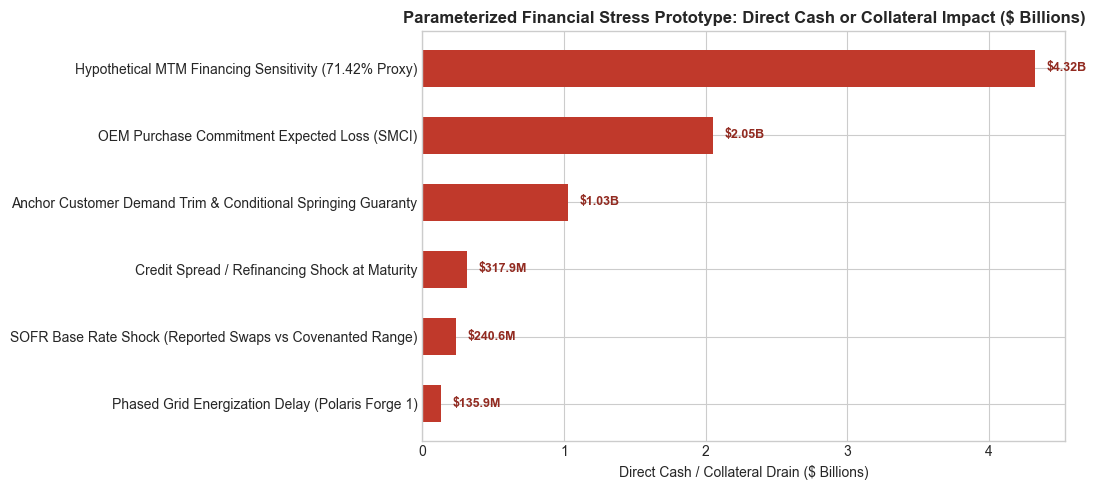

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
stress_plot = stress_summary.sort_values(by="direct_cash_or_collateral_hit_usd", ascending=True)
bars = ax.barh(stress_plot["scenario_name"], stress_plot["direct_cash_or_collateral_hit_usd"] / 1e9, color="#c0392b", height=0.55)
ax.set_title("Parameterized Financial Stress Prototype: Direct Cash or Collateral Impact ($ Billions)", fontsize=12, fontweight="bold")
ax.set_xlabel("Direct Cash / Collateral Drain ($ Billions)")

for bar in bars:
    w = bar.get_width()
    lbl = f"${w:.2f}B" if w >= 1.0 else f"${w*1000:.1f}M"
    ax.text(w + 0.08, bar.get_y() + bar.get_height()/2, lbl, va="center", fontsize=9, fontweight="bold", color="#922b21")

plt.tight_layout()
plt.savefig(project_root / "outputs/figures/financial_stress_waterfall.png", dpi=300)
plt.show()


## 7. Verifiable Evidence Ledger (Audit Receipts)

Every contractual assertion in this notebook is backed by an audited SEC EDGAR citation in `data/processed/evidence_claims.parquet`.
Below are the exact verbatim excerpts and accession numbers proving the $11.0B Polaris Forge lease, the $35.551B debt structure, the SPV springing guarantees, the $34.2B SMCI commitments, the 95% swap covenants, and the 67% Microsoft concentration.


In [13]:
claims_df = pd.read_parquet(project_root / "data/processed/evidence_claims.parquet")
claims_df[["claim_id", "entity_id", "filing_type", "filing_date", "section_locator", "exact_quote", "evidence_class"]]


,claim_id,entity_id,filing_type,filing_date,section_locator,exact_quote,evidence_class
0,CLM-APLD-001,APLD,10-K,2026-07-29,Item 1. Business - Data Center Leases,"On May 28, 2025, our subsidiaries APLD ELN-02 LLC and APLD ELN-03 LLC each entered into a data center lease (the 'EL...",A
1,CLM-APLD-002,APLD,10-K,2026-07-29,Note 14. Commitments and Contingencies - Data Center Leases,"On March 30, 2026, CoreWeave entered into an Assignment, Assumption and Consent Agreement with CoreWeave SPV and APL...",A
2,CLM-APLD-003,APLD,10-K,2026-07-29,Note 8. Financing Arrangements and Notes Payable,"The Company's indebtedness includes $2,350.0 million aggregate principal amount of 9.25% Senior Secured Notes due 20...",A
3,CLM-APLD-004,APLD,10-K,2026-07-29,Item 1. Business - Campus Construction Phasing,"At our Ellendale, North Dakota campus (Polaris Forge 1), Building 2 represents 100 MW of fully operational HPC capac...",A
4,CLM-APLD-005,APLD,8-K/A,2026-04-01,Exhibit 10.1 - Unconditional Springing Guaranty Agreement (APLD ELN-02 LLC),"As used herein, the term 'Springing Events' shall include the following: (i) the receipt by the Equipment Financing ...",A
5,CLM-APLD-006,APLD,8-K/A,2026-04-01,Exhibit 10.2 - Unconditional Springing Guaranty Agreement (APLD ELN-03 LLC),"Unconditional Springing Guaranty of Payment and Performance, dated March 30, 2026, by and between APLD ELN-03 LLC an...",A
6,CLM-CRWV-001,CRWV,10-Q,2026-08-12,Note 7. Debt - Debt Principal Maturities Table,"Years Ending December 31, Amount: Remaining portion of 2026: $4,413; 2027: $6,184; 2028: $4,416; 2029: $2,421; 2030:...",A
7,CLM-CRWV-002,CRWV,10-Q,2026-08-12,Note 7. Debt - Credit Facilities and Term Loans,"DDTL 1.0 Facility Mar 2028: $1,300; DDTL 2.0 Facility Aug 2030: $3,190; DDTL 2.1 Facility Mar 2031: $3,000; DDTL 3.0...",A
8,CLM-CRWV-003,CRWV,10-K,2026-03-02,Note 17. Customer Concentration and Segment Disclosures,A substantial portion of our revenue is driven by a limited number of customers. We recognized an aggregate of appro...,A
9,CLM-CRWV-004,CRWV,10-Q,2026-08-12,Note 7. Debt - Non-Recourse SPV Financing & DDTL 4.0,"As of June 30, 2026, the aggregate principal amount outstanding under our non-recourse project facilities was $3,719...",A


## 8. Synthesis & Computational Sketchbook Findings

### What Phase 0.7.1 Established
1. **The Bubble Lives in the Joins:** On consolidated statements, Applied Digital appears as a standalone host with $1.59B in cash and $4.98B in debt. But through the join at Polaris Forge 1 ($11.0B 15-year lease with CoreWeave), APLD's cash flows are tied to CoreWeave's solvency.
2. **Perimeter Opacity & Split Springing Guarantees:** CoreWeave executed separate **Unconditional Springing Guarantees** for Building 2 ($2.75B) and Building 3 ($4.13B), totaling $6.88B across 250 MW. If the Colocation Customer defaults or reduces payments, Springing Event (ii) activates parent liability. Building 4 ($4.13B, 150 MW) is guaranteed by APLD, not CoreWeave parent.
3. **Exact Debt Reconciliation:** Reconciled CoreWeave's indebtedness to the dollar with the **$35.551B** principal total across 11 modeled debt components/edges (including $2.837B DDTL 4.0 and $882M non-recourse OEM financing).
4. **Rate Transmission Grounded in Swaps:** Anchored on CoreWeave's audited $4.66B interest rate swap notional, revealing that $7.55B in floating debt is unhedged, generating an immediate $240.6M/yr network cash drain (sensitivity band: $32.6M to $309.2M/yr). Maturing debt faces a $317.9M/yr refinancing penalty by 2027.
5. **Building-Level Operational Phasing:** Modeled Polaris Forge 1 building phasing (~150 MW operational producing $275M base rent vs ~250 MW pending expansion), with carrying costs evaluated across a sensitivity band of 6.8% to 9.4% of cash.
6. **Accounting vs. Cash Liquidity Separation:** Rigorously separated Supermicro's non-cash $2.05B NRV loss provision on equity from working capital inventory cash outflows ($769M cancellation fee vs $5.13B delivery).
